# 15_snorkel_labeling

This notebook orchestrates weak supervision with Snorkel.

Workflow:
1. Add `src/` to the Python path
2. Import project config and labeling functions
3. Load the processed modeling table
4. Prepare the dataframe for LF application
5. Apply labeling functions
6. Inspect LF diagnostics
7. Fit the `LabelModel`
8. Generate `renegotiation_prob` and `target_renegotiate`
9. Create a few summary tables/plots
10. Save the weak-labeled dataset and diagnostics

In [34]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("project_root:", project_root)
print("src_path:", src_path)

project_root: /Users/Thomas/Desktop/Master Thesis
src_path: /Users/Thomas/Desktop/Master Thesis/src


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from snorkel.labeling import LFAnalysis, PandasLFApplier
from snorkel.labeling.model import LabelModel

from master_thesis.config import DATA_PROCESSED, TABLES, SEED
from master_thesis.snorkel_lfs import (
    ABSTAIN,
    NO,
    YES,
    LF_GROUPS,
    ALL_LFS,
    prepare_snorkel_dataframe,
)

## Load processed modeling table

This notebook expects the final engineered modeling table to exist in
`Data/processed/contract_final_no_spend.csv`.

In [36]:
input_path = DATA_PROCESSED / "contracts_with_features.csv"
df = pd.read_csv(input_path, low_memory=False)

print("Loaded:", input_path)
print("Shape:", df.shape)
print("Column count:", len(df.columns))
print("Unique contracts:", df["contract_id"].nunique() if "contract_id" in df.columns else "N/A")
df.head()


Loaded: /Users/Thomas/Desktop/Master Thesis/Data/processed/contracts_with_features.csv
Shape: (9201, 157)
Column count: 157
Unique contracts: 2209


,contract_id,contract_name,contract_status,contract_owner_cost_centre,terminated,term_type,start_date,expiration_date,supplier_id,supplier_number,...,market_flag_negative_eps,market_flag_stock_price_take_caution_or_worse,market_log_vol_shock_ratio,lpi_relative_risk,is_old_and_near_expiry,esg_row_missing_pct,news_row_missing_pct,lpi_below_supplier_median,years_to_expiry_capped,contracts_per_supplier
0,9675,Bioreliance_Master_2018_MSA,published,7756.0,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,0,0,NaN,1,0,93.333333,100.0,1,9.0,2
1,9675,Bioreliance_Master_2018_MSA,published,7756.0,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,0,0,NaN,1,0,93.333333,100.0,1,8.0,2
2,9675,Bioreliance_Master_2018_MSA,published,7756.0,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,0,0,NaN,1,0,93.333333,100.0,1,7.0,2
3,9675,Bioreliance_Master_2018_MSA,published,7756.0,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,0,0,NaN,1,0,93.333333,100.0,1,6.0,2
4,9675,Bioreliance_Master_2018_MSA,published,7756.0,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,0,0,NaN,1,0,93.333333,100.0,1,5.0,2


## LF input validation before weak supervision
In weak supervision, a labeling function that always abstains because its required input column is missing contributes no information to the label model, yet it typically fails silently. This is a methodological risk rather than a harmless implementation detail: silent abstentions increase the effective abstain rate and can distort the probability estimates learned by the label model. The validation block below therefore serves as an explicit quality-control gate between feature engineering and LF application by checking that all LF-critical columns are present before any weak labels are generated.


In [37]:
required_lf_columns = [
    "open_ended_contract", "days_until_expiry", "has_environmental_appendix", "contracts_per_supplier", "years_to_expiry_capped",
    "esg_esg_industry_adjusted", "fin_flag_negative_ebit_margin",
    "fin_flag_multiple_financial_stress_signals", "LPI_Score", "PPI_Value",
    "lpi_below_supplier_median", "is_old_and_near_expiry",
    "esg_below_industry_min", "supplier_is_publicly_listed", "payment_terms",
    "incoterms", "contract_age_years", "expiry_pressure_bucket", "department",
    "contracts_per_supplier", "open_ended_contract", "contract_name",
    "contract_type", "nn_contract_type", "contract_commodity"
]

missing_lf_columns = []
for col in required_lf_columns:
    if col in df.columns:
        print(f"OK      | {col}")
    else:
        print(f"MISSING | {col}")
        missing_lf_columns.append(col)

if missing_lf_columns:
    print("WARNING: The following columns are missing from the feature dataset. LFs depending on them will silently return ABSTAIN.")
    print(missing_lf_columns)
else:
    print("All required LF columns are present in the dataset.")


OK      | open_ended_contract
MISSING | days_until_expiry
MISSING | has_environmental_appendix
OK      | contracts_per_supplier
OK      | years_to_expiry_capped
OK      | esg_esg_industry_adjusted
OK      | fin_flag_negative_ebit_margin
OK      | fin_flag_multiple_financial_stress_signals
OK      | LPI_Score
OK      | PPI_Value
OK      | lpi_below_supplier_median
OK      | is_old_and_near_expiry
OK      | esg_below_industry_min
OK      | supplier_is_publicly_listed
OK      | payment_terms
OK      | incoterms
OK      | contract_age_years
OK      | expiry_pressure_bucket
OK      | department
OK      | contracts_per_supplier
OK      | open_ended_contract
OK      | contract_name
OK      | contract_type
OK      | nn_contract_type
OK      | contract_commodity
['days_until_expiry', 'has_environmental_appendix']


## Prepare dataframe for labeling functions

In [38]:
df_snorkel = prepare_snorkel_dataframe(df)

print("Prepared shape:", df_snorkel.shape)
df_snorkel.head()

Prepared shape: (9201, 159)


,contract_id,contract_name,contract_status,contract_owner_cost_centre,terminated,term_type,start_date,expiration_date,supplier_id,supplier_number,...,market_log_vol_shock_ratio,lpi_relative_risk,is_old_and_near_expiry,esg_row_missing_pct,news_row_missing_pct,lpi_below_supplier_median,years_to_expiry_capped,contracts_per_supplier,contract_name_lower,has_environmental_appendix
0,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,NaN,1,0,93.333333,100.0,1,9.0,2,bioreliance_master_2018_msa,NaN
1,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,NaN,1,0,93.333333,100.0,1,8.0,2,bioreliance_master_2018_msa,NaN
2,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,NaN,1,0,93.333333,100.0,1,7.0,2,bioreliance_master_2018_msa,NaN
3,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,NaN,1,0,93.333333,100.0,1,6.0,2,bioreliance_master_2018_msa,NaN
4,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,NaN,1,0,93.333333,100.0,1,5.0,2,bioreliance_master_2018_msa,NaN


## Quick sanity checks

In [39]:
print("Departments:", df_snorkel["department"].nunique(dropna=False) if "department" in df_snorkel.columns else "N/A")
print("Rows per department:")
if "department" in df_snorkel.columns:
    display(
        df_snorkel.groupby("department", dropna=False)
        .size()
        .reset_index(name="row_count")
        .sort_values("row_count", ascending=False)
        .head(20)
    )

Departments: 15
Rows per department:


,department,row_count
3,Devices & Needles,2197
11,Raw Materials & Energy,1555
9,Packaging Material,1272
10,"Quality, Production Services & Supplies",1044
5,Drug Substance Outsourcing,943
1,Bioprocessing & Raw Materials,679
4,Drug Product Outsourcing,589
8,Logistics,282
0,"Alliance, Acquisitions & PPM CoE",270
2,Bioprocessing and Excipients,218


## Apply labeling functions

In [40]:
applier = PandasLFApplier(lfs=ALL_LFS)
L = applier.apply(df=df_snorkel)

print("Label matrix shape:", L.shape)

100%|██████████| 9201/9201 [00:01<00:00, 6127.26it/s]


Label matrix shape: (9201, 39)


## Labeling function diagnostics

In [41]:
lf_summary = LFAnalysis(L=L, lfs=ALL_LFS).lf_summary()
lf_summary = lf_summary.sort_values(["Coverage", "Overlaps", "Conflicts"], ascending=False)

display(lf_summary.head(50))

/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/snorkel/labeling/analysis.py:61: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  m = sparse.diags(np.ravel(self._L_sparse.max(axis=1).todense()))


,j,Polarity,Coverage,Overlaps,Conflicts
lf_global_many_contracts_same_supplier,25,[1],0.728290,0.727856,0.065428
lf_global_high_ppi_pressure,28,[1],0.680143,0.641887,0.075101
lf_global_lpi_relative_risk,29,[1],0.434409,0.355940,0.015759
lf_global_old_perpetual_contract,0,[1],0.247038,0.246604,0.017389
lf_global_financial_rating_weak,6,[1],0.196283,0.196283,0.034888
lf_global_open_ended_and_old_and_many_contracts,26,[1],0.186067,0.186067,0.014564
lf_global_old_contract,1,[1],0.154114,0.154114,0.009564
lf_global_financial_multiple_stress,5,[1],0.109227,0.109227,0.001304
lf_global_esg_low_env_or_social,14,[1],0.061080,0.061080,0.014455
lf_global_financial_no_signal_strong_liquidity,11,[0],0.052603,0.052603,0.052603


## Zero-coverage LF quality check
A labeling function with exactly zero coverage returns `ABSTAIN` for every row. In practice, this often indicates a broken column reference or an upstream feature-engineering mismatch rather than a genuinely conservative rule. Because such failures do not raise runtime errors, they must be surfaced explicitly. The check below flags any LF whose coverage is exactly zero so that feature dependencies can be reviewed before trusting the weak-label distribution.


In [42]:
zero_coverage_lfs = lf_summary.loc[lf_summary["Coverage"] == 0.0].copy()

if zero_coverage_lfs.empty:
    print("No labeling functions have zero coverage.")
else:
    print("Labeling functions with zero coverage:")
    for lf_name in zero_coverage_lfs.index.tolist():
        print(f"WARNING: {lf_name} returns ABSTAIN for all rows. Check if its required column is missing from the dataset.")
    display(zero_coverage_lfs)


Labeling functions with zero coverage:


,j,Polarity,Coverage,Overlaps,Conflicts
lf_global_expiry_pressure_bucket,2,[],0.0,0.0,0.0
lf_global_market_public_stress,24,[],0.0,0.0,0.0
lf_global_low_lpi,27,[],0.0,0.0,0.0
lf_logistics_expired_or_near_expiry,30,[],0.0,0.0,0.0
lf_logistics_low_lpi,32,[],0.0,0.0,0.0


## Note on zero-coverage labeling functions
Zero-coverage LFs should be reviewed against the `required_lf_columns` output above. If a column shows `MISSING` in the validation output and an LF targeting that column shows zero coverage below, the cause is a feature engineering mismatch rather than an overly conservative rule threshold. The fix in that case is to restore the missing column in the feature engineering notebook and regenerate `contracts_with_features.csv` before re-running this notebook. Do not adjust LF thresholds to compensate for missing input columns.


In [43]:
group_summary_rows = []

for group_name, group_lfs in LF_GROUPS.items():
    group_names = [lf.name for lf in group_lfs]
    group_df = lf_summary.loc[group_names].copy()

    row = {
        "group": group_name,
        "n_lfs": len(group_lfs),
        "avg_coverage": group_df["Coverage"].mean(),
        "avg_overlap": group_df["Overlaps"].mean(),
        "avg_conflict": group_df["Conflicts"].mean(),
        "total_polarity_classes": group_df["Polarity"].apply(lambda x: len(x) if isinstance(x, list) else 0).sum(),
    }
    group_summary_rows.append(row)

group_summary = pd.DataFrame(group_summary_rows).sort_values("avg_coverage", ascending=False)
display(group_summary)

,group,n_lfs,avg_coverage,avg_overlap,avg_conflict,total_polarity_classes
5,global_supplier_macro,5,0.405782,0.382350,0.034170,4
0,global_lifecycle,4,0.100478,0.100370,0.006738,3
1,global_financial,8,0.058064,0.058064,0.011928,8
2,global_esg,5,0.025171,0.025171,0.004804,5
3,global_news,4,0.015134,0.015107,0.006874,4
6,logistics_specific,9,0.013598,0.013598,0.000869,7
4,global_market,4,0.002880,0.002880,0.000489,3


## Fit LabelModel

In [44]:
label_model = LabelModel(cardinality=2, verbose=True)
label_model.fit(
    L_train=L,
    n_epochs=500,
    log_freq=100,
    seed=SEED
)

INFO:root:Computing O...
INFO:root:Estimating \mu...
  0%|          | 0/500 [00:00<?, ?epoch/s]INFO:root:[0 epochs]: TRAIN:[loss=1.863]
INFO:root:[100 epochs]: TRAIN:[loss=0.129]


INFO:root:[200 epochs]: TRAIN:[loss=0.112]
 54%|█████▍    | 269/500 [00:00<00:00, 2666.98epoch/s]INFO:root:[300 epochs]: TRAIN:[loss=0.077]
INFO:root:[400 epochs]: TRAIN:[loss=0.076]
100%|██████████| 500/500 [00:00<00:00, 2810.53epoch/s]
INFO:root:Finished Training


## Generate weak labels

In [45]:
probs = label_model.predict_proba(L)

df_snorkel["renegotiation_prob"] = probs[:, 1]
df_snorkel["target_renegotiate"] = (df_snorkel["renegotiation_prob"] >= 0.5).astype(int)

df_snorkel[["renegotiation_prob", "target_renegotiate"]].head()

,renegotiation_prob,target_renegotiate
0,0.621413,1
1,0.621413,1
2,0.621413,1
3,0.621413,1
4,0.565277,1


In [46]:
print(df_snorkel["target_renegotiate"].value_counts(dropna=False))
print(df_snorkel["renegotiation_prob"].describe())

target_renegotiate
1    4910
0    4291
Name: count, dtype: int64
count    9201.000000
mean        0.549803
std         0.307150
min         0.000004
25%         0.400141
50%         0.522653
75%         0.999242
max         1.000000
Name: renegotiation_prob, dtype: float64


## Department-level summaries

In [47]:
if "department" in df_snorkel.columns:
    dept_summary = (
        df_snorkel.groupby("department", dropna=False)
        .agg(
            n_rows=("contract_id", "size"),
            n_contracts=("contract_id", "nunique"),
            avg_prob=("renegotiation_prob", "mean"),
            positive_share=("target_renegotiate", "mean"),
        )
        .reset_index()
        .sort_values("avg_prob", ascending=False)
    )
    display(dept_summary)

,department,n_rows,n_contracts,avg_prob,positive_share
0,"Alliance, Acquisitions & PPM CoE",270,35,0.760780,0.851852
11,Raw Materials & Energy,1555,281,0.649787,0.699035
2,Bioprocessing and Excipients,218,59,0.633646,0.623853
9,Packaging Material,1272,289,0.611310,0.615566
1,Bioprocessing & Raw Materials,679,113,0.586176,0.633284
10,"Quality, Production Services & Supplies",1044,215,0.561177,0.578544
5,Drug Substance Outsourcing,943,298,0.508359,0.453871
3,Devices & Needles,2197,476,0.497098,0.460173
13,"Strategy, Sourcing & Negotiation CoE",2,2,0.442026,0.000000
6,Global Strategic Outsourcing & Devices,23,8,0.406135,0.173913


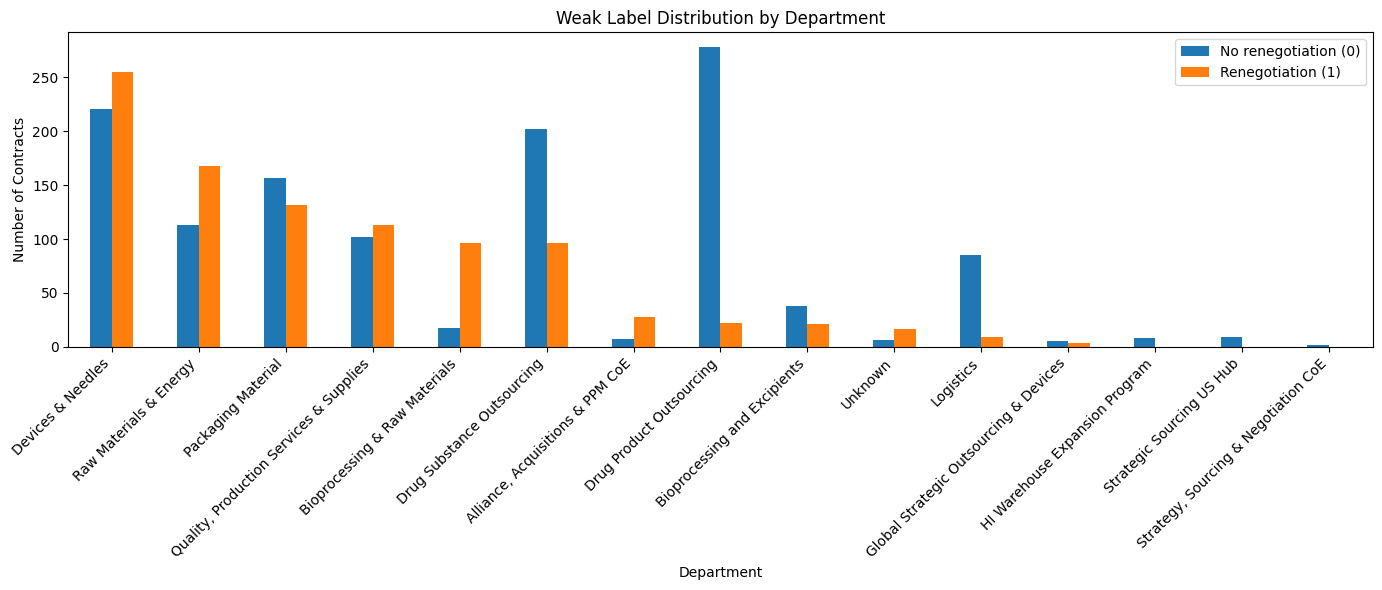

In [48]:
if "department" in df_snorkel.columns:
    df_plot = (
        df_snorkel[["contract_id", "department", "target_renegotiate"]]
        .drop_duplicates(subset=["contract_id"])
        .copy()
    )

    df_plot["department"] = df_plot["department"].fillna("Unknown")

    dept_counts = (
        df_plot.groupby(["department", "target_renegotiate"])
        .size()
        .unstack(fill_value=0)
    )

    if 0 not in dept_counts.columns:
        dept_counts[0] = 0
    if 1 not in dept_counts.columns:
        dept_counts[1] = 0

    dept_counts = dept_counts[[0, 1]].sort_values(1, ascending=False)

    ax = dept_counts.plot(kind="bar", figsize=(14, 6))
    ax.set_title("Weak Label Distribution by Department")
    ax.set_xlabel("Department")
    ax.set_ylabel("Number of Contracts")
    ax.legend(["No renegotiation (0)", "Renegotiation (1)"])
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [49]:
# --- [DEBUG MODE] VALIDATION ---
print("Labeled Dataset Statistics:")
print(f"  - Total Rows: {len(df_snorkel)}")
print(f"  - Unique Contracts: {df_snorkel['contract_id'].nunique()}")

if 'renegotiation_prob' in df_snorkel.columns:
    print("✅ Found 'renegotiation_prob' column.")
else:
    print("❌ WARNING: 'renegotiation_prob' missing!")

if 'target_renegotiate' in df_snorkel.columns:
    print("✅ Found 'target_renegotiate' column.")
else:
    print("❌ WARNING: 'target_renegotiate' missing!")

Labeled Dataset Statistics:
  - Total Rows: 9201
  - Unique Contracts: 2209
✅ Found 'renegotiation_prob' column.
✅ Found 'target_renegotiate' column.


## Save outputs

In [50]:
output_labeled = DATA_PROCESSED / "contract_with_features_labeled.csv"
output_lf_summary = TABLES / "snorkel_lf_summary.csv"
output_group_summary = TABLES / "snorkel_group_summary.csv"

df_snorkel.to_csv(output_labeled, index=False)
# Compatibility copy for older notebooks/scripts that referenced this filename.
df_snorkel.to_csv(DATA_PROCESSED / "contract_snorkel_labeled.csv", index=False)
lf_summary.to_csv(output_lf_summary, index=True)
group_summary.to_csv(output_group_summary, index=False)

print("Saved labeled dataset to:", output_labeled)
print("Saved LF summary to:", output_lf_summary)
print("Saved group summary to:", output_group_summary)

Saved labeled dataset to: /Users/Thomas/Desktop/Master Thesis/Data/processed/contract_with_features_labeled.csv
Saved LF summary to: /Users/Thomas/Desktop/Master Thesis/reports/tables/snorkel_lf_summary.csv
Saved group summary to: /Users/Thomas/Desktop/Master Thesis/reports/tables/snorkel_group_summary.csv


## Short interpretation

Use this section to add short written notes after each run, for example:
- Which LF groups had the highest coverage
- Whether conflicts look too high
- Whether the positive-label share looks reasonable
- Any departments that look over- or under-labeled